In [ ]:
!pip install keras tensorflow

In [ ]:
import os
import numpy as np
import tensorflow as tf
import keras as keras
from tensorflow import keras
from keras import layers
from google.colab import files
from tensorflow.keras import layers
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from sklearn.metrics import classification_report
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import zipfile
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Set random seed for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# Constants
IMG_HEIGHT, IMG_WIDTH = 128, 128
BATCH_SIZE = 16
EPOCHS = 250
VALIDATION_SPLIT = 0.2

In [ ]:
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

# Normalize and reshape data
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0
x_train = np.expand_dims(x_train, axis=-1) # Add channel dimension
x_test = np.expand_dims(x_test, axis=-1)

# Define a simple CNN model
model = keras.Sequential([
layers.Conv2D(32, (3, 3), activation="relu", input_shape=(28, 28, 1)),
layers.MaxPooling2D((2, 2)),
layers.Conv2D(64, (3, 3), activation="relu"),
layers.MaxPooling2D((2, 2)),
layers.Flatten(),
layers.Dense(128, activation="relu"),
layers.Dense(10, activation="softmax") # 10 classes for MNIST digits
])
# Compile the model
model.compile(optimizer="adam",

loss="sparse_categorical_crossentropy",
metrics=["accuracy"])

# Train the model
model.fit(x_train, y_train, epochs=5, batch_size=32, validation_data=(x_test, y_test))

# Evaluate the model
test_loss, test_acc = model.evaluate(x_test, y_test)
print(f"Test accuracy: {test_acc:.4f}")

# Make predictions
predictions = model.predict(x_test[:5])
predicted_labels = np.argmax(predictions, axis=1)
print("Predicted labels:", predicted_labels)
print("Actual labels: ", y_test[:5])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 84s 44ms/step - accuracy: 0.9612 - loss: 0.1253 - val_accuracy: 0.9848 - val_loss: 0.0448
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 57s 30ms/step - accuracy: 0.9870 - loss: 0.0416 - val_accuracy: 0.9868 - val_loss: 0.0398
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 83s 31ms/step - accuracy: 0.9921 - loss: 0.0268 - val_accuracy: 0.9851 - val_loss: 0.0483
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 56s 30ms/step - accuracy: 0.9946 - loss: 0.0178 - val_accuracy: 0.9846 - val_loss: 0.0564
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 85s 32ms/step - accuracy: 0.9956 - loss: 0.0139 - val_accuracy: 0.9857 - val_loss: 0.0506
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.9857 - loss: 0.0506
Test accuracy: 0.9857
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 456ms/step
Predicted labels: [7 2 1 0 4]
Actual labels:  [7 2 1 0 4]


Checking paths...
Train path exists: True
Test path exists: True

Loading training data...
Found classes: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']
Loading class: acai (label: 0)
Loading class: cupuacu (label: 1)
Loading class: graviola (label: 2)
Loading class: guarana (label: 3)
Loading class: pupunha (label: 4)
Loading class: tucuma (label: 5)

Loading testing data...
Found classes: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']
Loading class: acai (label: 0)
Loading class: cupuacu (label: 1)
Loading class: graviola (label: 2)
Loading class: guarana (label: 3)
Loading class: pupunha (label: 4)
Loading class: tucuma (label: 5)

Training set: (90, 128, 128, 1), Labels: (90, 6)
Testing set: (30, 128, 128, 1), Labels: (30, 6)


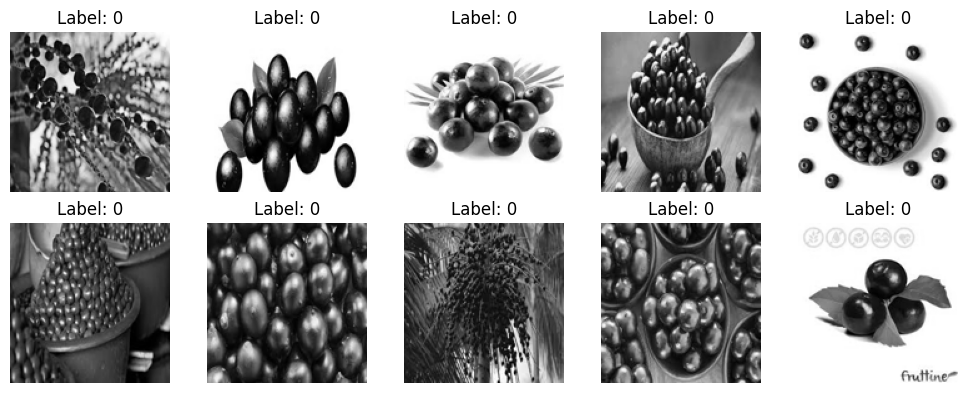

In [ ]:

train_dir = '/content/drive/MyDrive/ai Workshop Dataset/FruitinAmazon/train/'
test_dir = '/content/drive/MyDrive/ai Workshop Dataset/FruitinAmazon/test/'

def load_images_from_folder(folder):
    images = []
    labels = []

    # Check if folder exists
    if not os.path.exists(folder):
        raise FileNotFoundError(f"Folder not found: {folder}. Please check your path.")

    class_names = sorted([d for d in os.listdir(folder) if os.path.isdir(os.path.join(folder, d))])
    print(f"Found classes: {class_names}")

    class_map = {name: i for i, name in enumerate(class_names)}

    for class_name in class_names:
        class_path = os.path.join(folder, class_name)
        label = class_map[class_name]

        print(f"Loading class: {class_name} (label: {label})")

        for filename in os.listdir(class_path):
            if filename.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.gif')):
                img_path = os.path.join(class_path, filename)
                try:
                    # Load image using PIL
                    img = Image.open(img_path).convert("L")  # Convert to grayscale
                    img = img.resize((IMG_WIDTH, IMG_HEIGHT))  # Resize to (28,28)
                    img = np.array(img) / 255.0  # Normalize pixel values to [0,1]
                    images.append(img)
                    labels.append(label)
                except Exception as e:
                    print(f"Error loading {img_path}: {e}")
                    continue

    return np.array(images), np.array(labels)

# Verify paths exist before loading
print("Checking paths...")
print(f"Train path exists: {os.path.exists(train_dir)}")
print(f"Test path exists: {os.path.exists(test_dir)}")

# Load training and testing datasets
print("\nLoading training data...")
x_train, y_train = load_images_from_folder(train_dir)

print("\nLoading testing data...")
x_test, y_test = load_images_from_folder(test_dir)

# Reshape images for Keras input
x_train = x_train.reshape(-1, IMG_HEIGHT, IMG_WIDTH, 1)
x_test = x_test.reshape(-1, IMG_HEIGHT, IMG_WIDTH, 1)

# One-hot encode labels
y_train = to_categorical(y_train, num_classes=6)
y_test = to_categorical(y_test, num_classes=6)

# Print dataset shape
print(f"\nTraining set: {x_train.shape}, Labels: {y_train.shape}")
print(f"Testing set: {x_test.shape}, Labels: {y_test.shape}")

# Visualize some images
plt.figure(figsize=(10, 4))
for i in range(min(10, len(x_train))):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i].reshape(128, 128), cmap='gray')
    plt.title(f"Label: {np.argmax(y_train[i])}")
    plt.axis("off")
plt.tight_layout()
plt.show()

In [ ]:
# Create a preprocessing layer for normalization
rescale = tf.keras.layers.Rescaling(1./255) # Normalize pixel values to [0, 1]
# Create training dataset with normalization
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
train_dir,
labels='inferred',
label_mode='int',
image_size=(IMG_HEIGHT, IMG_WIDTH),
interpolation='nearest',
batch_size=BATCH_SIZE ,
shuffle=True,
validation_split=VALIDATION_SPLIT,
subset='training',
seed=123
)
train_ds = train_ds.map(lambda x, y: (rescale(x), y))

# Create validation dataset with normalization
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
train_dir,
labels='inferred',
label_mode='int',
image_size=(IMG_HEIGHT, IMG_WIDTH),
interpolation='nearest',
batch_size=BATCH_SIZE ,
shuffle=False,
validation_split=VALIDATION_SPLIT,
subset='validation',
seed=123
)
# Apply the normalization (Rescaling) to the validation dataset
val_ds = val_ds.map(lambda x, y: (rescale(x), y))

# Create validation dataset with normalization
test_ds = tf.keras.preprocessing.image_dataset_from_directory(
test_dir,
labels='inferred',
label_mode='int',
image_size=(IMG_HEIGHT, IMG_WIDTH),
interpolation='nearest',
batch_size=BATCH_SIZE ,
shuffle=False,
)
# Apply the normalization (Rescaling) to the validation dataset
test_ds = test_ds.map(lambda x, y: (rescale(x), y))

Found 90 files belonging to 6 classes.
Using 72 files for training.
Found 90 files belonging to 6 classes.
Using 18 files for validation.
Found 30 files belonging to 6 classes.


In [ ]:
input_shape = (IMG_HEIGHT, IMG_WIDTH, 3)
model = keras.Sequential([
layers.Conv2D(32, (3, 3), padding='same', strides=1, activation="relu",input_shape=input_shape ),
layers.MaxPooling2D((2, 2), strides=2),
layers.Conv2D(32, (3, 3), padding='same', strides=1, activation="relu"),
layers.MaxPooling2D((2, 2), strides=2),
layers.Flatten(),
layers.Dense(64, activation="relu"),
layers.Dense(128, activation="relu"),
layers.Dense(6, activation="softmax")
])


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(optimizer="adam",
loss="sparse_categorical_crossentropy",
metrics=["accuracy"])

In [ ]:
model.summary()

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_18 (Conv2D)              │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_18 (MaxPooling2D) │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_19 (MaxPooling2D) │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_9 (Flatten)             │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 64)             │     2,097,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,116,454 (8.07 MB)

 Trainable params: 2,116,454 (8.07 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Define the callbacks
checkpoint = ModelCheckpoint(
    'best_model.h5',
    monitor='val_loss',
    save_best_only=True,
    mode='max',
    verbose=1
)

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

# Train the model
history = model.fit(
        train_ds,
        epochs=EPOCHS,
        validation_data=val_ds,
        batch_size=BATCH_SIZE,
        callbacks=[checkpoint, early_stopping],
        verbose=1
)

Epoch 1/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 238ms/step - accuracy: 0.1330 - loss: 2.7741
Epoch 1: val_loss improved from None to 1.85442, saving model to best_model.h5



Epoch 1: finished saving model to best_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 358ms/step - accuracy: 0.1389 - loss: 2.8980 - val_accuracy: 0.0000e+00 - val_loss: 1.8544
Epoch 2/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 246ms/step - accuracy: 0.1719 - loss: 1.7722
Epoch 2: val_loss did not improve from 1.85442
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 333ms/step - accuracy: 0.1667 - loss: 1.8161 - val_accuracy: 0.6667 - val_loss: 1.5836
Epoch 3/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 241ms/step - accuracy: 0.2500 - loss: 1.7709
Epoch 3: val_loss did not improve from 1.85442
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 290ms/step - accuracy: 0.2500 - loss: 1.7509 - val_accuracy: 0.0000e+00 - val_loss: 1.7941
Epoch 4/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 241ms/step - accuracy: 0.4038 - loss: 1.6687
Epoch 4: val_loss did not improve from 1.85442
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 289ms/step - accuracy: 0.3889 - loss: 1.6647 - val_accuracy: 0.1111 - val_loss: 1.6855
Epoch 5/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 371ms/step - accuracy: 0.4771 - loss: 1.5276
Ep

In [ ]:
# TASK 5: Model Evaluation
test_loss, test_accuracy = model.evaluate(test_ds, verbose=1)
print(f"\nTest Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step - accuracy: 0.7000 - loss: 1.1422

Test Loss: 1.1422
Test Accuracy: 0.7000


In [ ]:
# Save model to .h5 file
model_filename = 'Krishna_Lal_Bomjan_amazon_fruits_cnn_model.h5'
model.save(model_filename)
print(f"Model saved as: {model_filename}")

# Load the saved model
loaded_model = keras.models.load_model(model_filename)
print("Model loaded successfully")

# Re-evaluate loaded model
print("\nRe-evaluating loaded model...")
loaded_loss, loaded_acc = loaded_model.evaluate(test_ds, verbose=1)
print(f"Loaded Model - Test Loss: {loaded_loss:.4f}, Test Accuracy: {loaded_acc:.4f}")

Model saved as: Giri_Bahadur_Karki_amazon_fruits_cnn_model.h5
Model loaded successfully

Re-evaluating loaded model...
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 180ms/step - accuracy: 0.7000 - loss: 1.1422
Loaded Model - Test Loss: 1.1422, Test Accuracy: 0.7000


In [ ]:
files.download(model_filename)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


Classification Report:
              precision    recall  f1-score   support

           0     0.5556    1.0000    0.7143         5
           1     1.0000    1.0000    1.0000         5
           2     1.0000    0.8000    0.8889         5
           3     1.0000    0.2000    0.3333         5
           4     0.6000    0.6000    0.6000         5
           5     0.5000    0.6000    0.5455         5

    accuracy                         0.7000        30
   macro avg     0.7759    0.7000    0.6803        30
weighted avg     0.7759    0.7000    0.6803        30



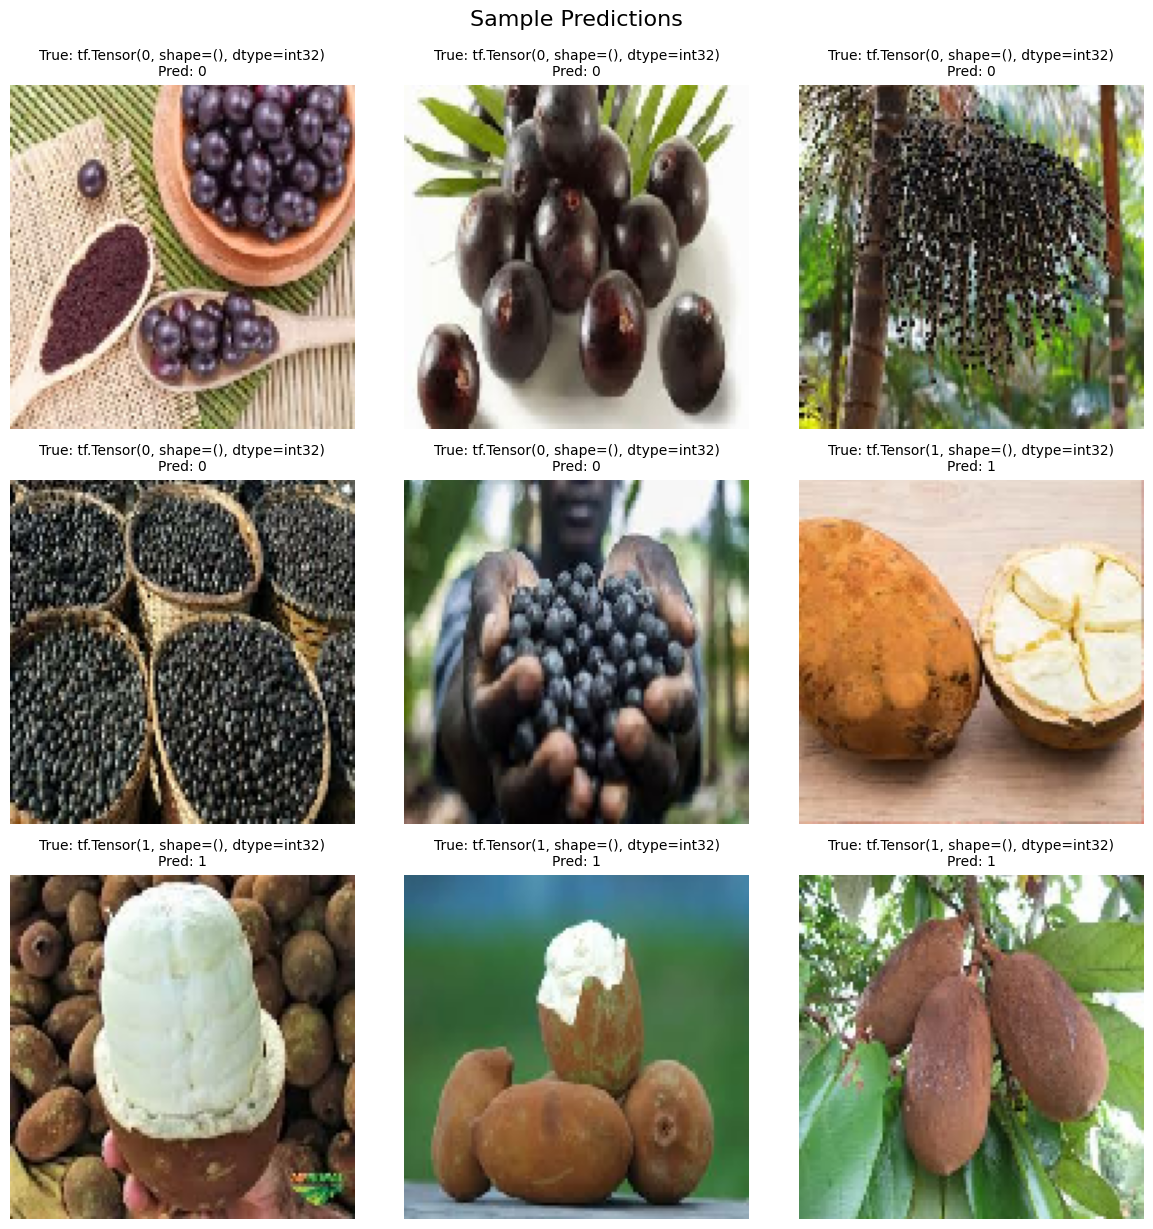

In [ ]:
class_names = test_ds.class_names if hasattr(test_ds, 'class_names') else None

# Get all test images and labels
y_true = []
y_pred = []

# Iterate through test dataset
for images, labels in test_ds:
    predictions = model.predict(images, verbose=0)
    predicted_labels = np.argmax(predictions, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(predicted_labels)

y_true = np.array(y_true)
y_pred = np.array(y_pred)

# Generate classification report
if class_names:
    report = classification_report(y_true, y_pred, target_names=class_names, digits=4)
else:
    report = classification_report(y_true, y_pred, digits=4)

print("\nClassification Report:")
print(report)

# Display some sample predictions
plt.figure(figsize=(12, 12))
for images, labels in test_ds.take(1):
    predictions = model.predict(images[:9], verbose=0)
    predicted_labels = np.argmax(predictions, axis=1)

    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy())
        true_label = class_names[labels[i]] if class_names else str(labels[i])
        pred_label = class_names[predicted_labels[i]] if class_names else str(predicted_labels[i])
        plt.title(f"True: {true_label}\nPred: {pred_label}", fontsize=10)
        plt.axis("off")

plt.tight_layout()
plt.suptitle('Sample Predictions', fontsize=16, y=1.02)
plt.show()

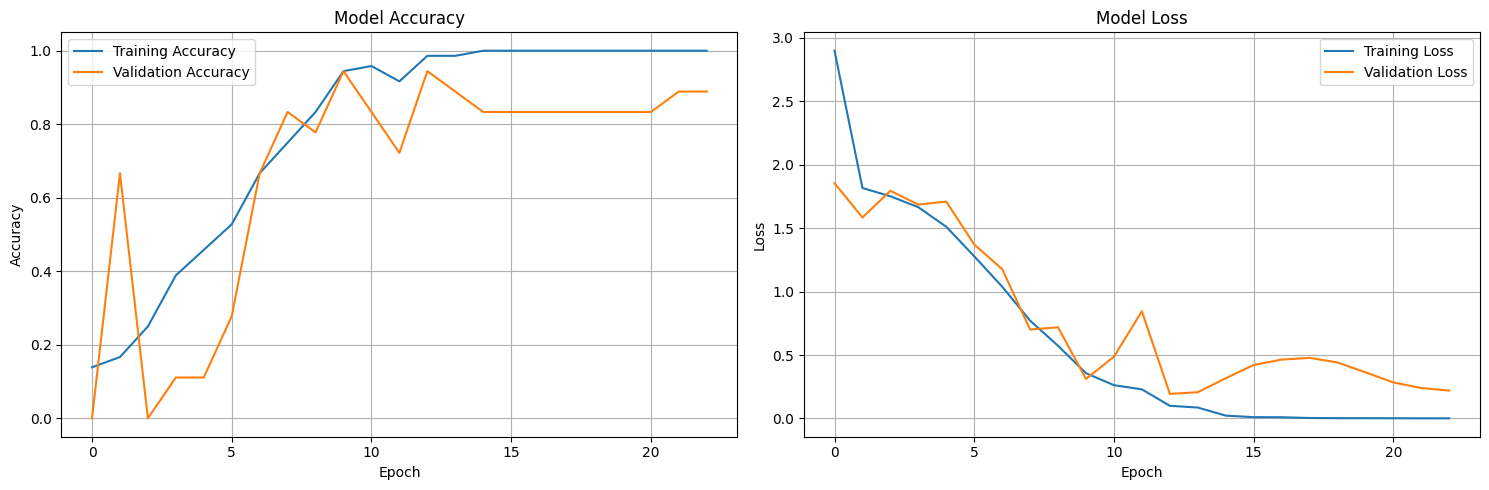

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Plot accuracy
ax1.plot(history.history['accuracy'], label='Training Accuracy')
ax1.plot(history.history['val_accuracy'], label='Validation Accuracy')
ax1.set_title('Model Accuracy')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True)

# Plot loss
ax2.plot(history.history['loss'], label='Training Loss')
ax2.plot(history.history['val_loss'], label='Validation Loss')
ax2.set_title('Model Loss')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()